# 🏫 **AICE ASSOCIATE 제2회 실전모의고사**


## **온라인 교육 플랫폼 회원 이탈 예측**
---
* **도메인** : 교육 서비스 / IT
* **목 표** : 회원 활동 데이터를 활용한 이탈 여부 예측 인공지능 모델 개발
* **'에듀-업(Edu-Up)'** **은** 꾸준히 성장하고 있으나, 매 분기 일정 비율의 회원이 서비스를 이탈하여 장기적인 성장에 걸림돌이 되고 있다.
* 지난 1년간 분기별로 축적된 회원의 수강 패턴, 활동량, 서비스 이용 기록의 변화를 심층적으로 분석하여 이탈 징후를 사전에 포착하고자 한다.
* 지난 1년간의 분기별 회원 활동 데이터를 기반으로 미래의 **회원 이탈 여부를 예측**하는 최적의 분류 모델을 개발한다.

---


### **[데이터셋 소개]**
* `q1_data.xlsx`: 1분기 회원 데이터
* `q2_data.xlsx`: 2분기 회원 데이터
* `q3_data.xlsx`: 3분기 회원 데이터
* `q4_data.xlsx`: 4분기 회원 데이터
* **모든 파일은 동일한 컬럼 구조를 가집니다.**

### **[컬럼 설명]**
- **age**: 사용자 나이
- **salary**: 사용자의 연간 추정 소득(단위: 원)
- **experience_years**: 해당 분야 또는 업무 경력(년 단위)
- **weekly_study_hours**: 주당 평균 학습 시간(시간)
- **courses_completed**: 수강 완료한 강의 수
- **login_days_past30**: 최근 30일 간 로그인한 총 일수
- **membership**: 회원 등급(예: basic, premium, vip 등)
- **device**: 주 사용 기기(예: desktop, mobile, tablet)
- **region**: 거주 지역(예: 서울특별시, 경기도 등)
- **promo_opt_in**: 마케팅 수신 동의 여부(1: 동의, 0: 비동의)
- **num_promo_emails_last3m**: 최근 3개월간 받은 프로모션 이메일 수
- **churn**: 이탈 여부(1: 이탈, 0: 유지) → **목표 변수**

#### **1. 분기별로 나누어진 회원 활동 데이터를 불러와 하나의 데이터프레임으로 통합하려 합니다. 아래 가이드에 따라 데이터를 불러오고 통합하세요.**

---
* 대상 파일: q1_data.xlsx, q2_data.xlsx, q3_data.xlsx, q4_data.xlsx
* pandas 라이브러리를 별칭 pd를 사용하여 임포트하세요.
* **`pandas`** 의 **`read_excel()`** 함수로 4개의 분기 데이터를 각각 불러오세요.
* **`concat()`** 함수를 사용하여 불러온 데이터프레임을 수직으로 통합하고 **`df`** 에 저장하세요.
* 통합 시 인덱스가 새로 부여되도록 **`ignore_index=True`** 옵션을 적용하세요.
* 상위 4개 데이터를 출력하세요.
---

In [1]:
import pandas as pd

df1 = pd.read_excel('q1_data.xlsx')
df2 = pd.read_excel('q2_data.xlsx')
df3 = pd.read_excel('q3_data.xlsx')
df4 = pd.read_excel('q4_data.xlsx')

df = pd.concat([df1, df2, df3, df4], ignore_index=True)

df.head()

,age,salary,experience_years,weekly_study_hours,courses_completed,login_days_past30,membership,device,region,promo_opt_in,num_promo_emails_last3m,churn
0,NaN,35922993.0,15,4.7,5,23,basic,desktop,서울특별시,1,2,0
1,33.0,41803885.0,15,6.2,2,27,premium,desktop,경기도,0,3,0
2,41.0,45766391.0,20,4.6,0,12,basic,mobile,경기도,1,4,0
3,50.0,65761614.0,29,9.5,4,29,basic,desktop,대전광역시,1,14,0
4,32.0,32555915.0,10,4.4,3,24,basic,tablet,광주광역시,0,11,1


> **<span style="color:red">다음 문항을 풀기 전에 </span>아래 코드를 실행하세요.**
>

In [2]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

#### **2. 수집된 데이터의 타겟 변수 분포를 확인하고 문제 유형을 판별하려 합니다. 아래 가이드에 따라 시각화를 수행하고 문제 유형을 판단하세요.**

---
* 대상 데이터프레임 : **`df`**
* (2-1) **`seaborn`** 라이브러리의 **`countplot()`** 함수를 사용하여 타겟 변수인 이탈 여부 (**`churn`**)의 분포를 시각화하세요.
* (2-2) 타겟 변수의 데이터 형태 (0: 유지, 1: 이탈) 를 확인하여 이 문제의 유형이 **'회귀'** 와 **'분류'** 중 무엇인지 판단하고 그 결과를 아래 정답 셀에 기입하세요.
---

<Axes: xlabel='churn', ylabel='count'>

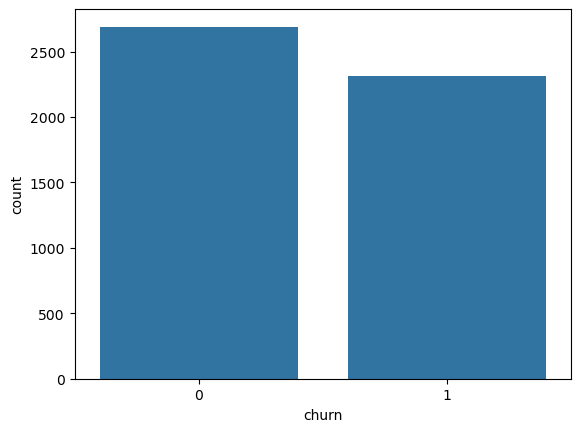

In [3]:
sns.countplot(df, x='churn')

In [ ]:
분류

#### **3. 회원 등급과 이탈 간의 관계를 분석하여 등급별 이탈 특성을 파악하고자 합니다. 아래 가이드에 따라 (3-1) 교차표를 생성하고 (3-2) 'vip' 등급의 이탈률을 계산하세요.**
---
* **(3-1) 회원 등급과 이탈 여부 간의 교차표를 생성하세요.**
    * 대상 데이터프레임: **`df`**
    * **`crosstab()`** 함수를 사용하여 회원 등급(**`membership`**)과 이탈 여부(**`churn`**)컬럼 간의 교차표를 생성하세요.
* **(3-2) 'vip' 등급 회원의 이탈률은 얼마인가요?**
    * 생성된 교차표를 바탕으로 **'vip'** 등급 회원들의 이탈률(%)을 계산하세요.
    * 이탈률 = (이탈(1)한 'vip' 회원 수 / 전체 'vip' 회원 수) * 100
    *  소수점 둘째 자리까지 반올림하여 아래 정답 셀에 기입하세요.
---

In [15]:
crosstab = pd.crosstab(df['membership'], df['churn'])

print(crosstab)

churn          0     1
membership            
basic       1079  1966
premium     1216   253
vip          395    91


In [19]:
churn_rate = (crosstab.loc['vip', 1] / crosstab.loc['vip'].sum()) * 100

print(round(churn_rate, 2))

18.72


#### **4. 데이터의 품질을 높이기 위해 각 컬럼의 특성에 맞는 대표값으로 결측치를 처리하고자 합니다. 아래 가이드에 따라 (4-1) 결측치 현황을 확인하고 (4-2) 적절한 값으로 결측치를 채우세요.**
---
* **(4-1) 데이터프레임의 컬럼별 결측치 개수를 확인하세요.**
    * 대상 데이터프레임: **`df`**
    * 각 컬럼에 포함된 결측치의 총 개수를 출력하세요.
* **(4-2) 각 컬럼의 특성에 따라 결측치를 대체하고 결과를 확인하세요.**
    * **`age`** 컬럼: 전체 평균(mean)으로 채우되, 소수점은 버리고 정수형(int)으로 변환하여 적용하세요.
    * **`salary`** 컬럼: 전체 중앙값(median)으로 채우세요.
    * **`weekly_study_hours`** 컬럼: 0으로 채우세요.
    * 모든 변경사항은 원본 **`df`** 에 즉시 반영하고, 최종적으로 결측치가 모두 처리되었는지 다시 한번 확인하세요.
---

In [20]:
df.isnull().sum()

age                        909
salary                     140
experience_years             0
weekly_study_hours          94
courses_completed            0
login_days_past30            0
membership                   0
device                       0
region                       0
promo_opt_in                 0
num_promo_emails_last3m      0
churn                        0
dtype: int64

In [24]:
df['age'] = df['age'].fillna(df['age'].mean())
df['salary'] = df['salary'].fillna(df['salary'].median())
df['weekly_study_hours'] = df['weekly_study_hours'].fillna(0)

df.isnull().sum()

age                        0
salary                     0
experience_years           0
weekly_study_hours         0
courses_completed          0
login_days_past30          0
membership                 0
device                     0
region                     0
promo_opt_in               0
num_promo_emails_last3m    0
churn                      0
dtype: int64

#### **5. 머신러닝 모델 학습을 위해 범주형 데이터를 수치형으로 변환하는 인코딩 작업을 수행하고자 합니다. 아래 가이드에 따라 (5-1) 잘못된 코드를 수정하여 인코딩을 수행하고 (5-2) 변환된 데이터의 구조를 확인하세요.**
---
* **(5-1) 제공된 코드의 오류를 수정하여 범주형 컬럼에 대한 원-핫 인코딩(One-hot Encoding)을 수행하세요.**
    * 대상 데이터프레임 : **`df`**
    * **`membership`**, **`device`**, **`region`** 컬럼을 대상으로 원-핫 인코딩을 진행하고 그 결과를 **`df_encoded`** 변수에 저장하세요.
    * 정보의 중복을 방지하기 위해 첫 번째 카테고리를 제외하는 **`drop_first=True`** 옵션을 반드시 적용하세요.
    * **`info()`** 함수를 사용하여 **`df_encoded`** 의 전체 컬럼 개수를 확인하세요.
* **(5-2) 인코딩 결과 생성된 데이터프레임의 컬럼은 총 몇 개인가요?**
---

In [25]:
# (5-1) 여기에 코드의 오류를 정정하고 실행하세요.
df_encoded = pd.get_dummies(df, columns=['membership', 'device', 'region'], drop_first=True)
df_encoded.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 20 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   age                      5000 non-null   float64
 1   salary                   5000 non-null   float64
 2   experience_years         5000 non-null   int64  
 3   weekly_study_hours       5000 non-null   float64
 4   courses_completed        5000 non-null   int64  
 5   login_days_past30        5000 non-null   int64  
 6   promo_opt_in             5000 non-null   int64  
 7   num_promo_emails_last3m  5000 non-null   int64  
 8   churn                    5000 non-null   int64  
 9   membership_premium       5000 non-null   bool   
 10  membership_vip           5000 non-null   bool   
 11  device_mobile            5000 non-null   bool   
 12  device_tablet            5000 non-null   bool   
 13  region_광주광역시             5000 non-null   bool   
 14  region_대구광역시            

In [ ]:
20

#### **6. 모델 학습을 위해 데이터프레임을 독립변수(X)와 종속변수(y)로 분리하고자 합니다. 아래 가이드에 따라 (6-1) 피처와 타깃 데이터를 분리하고, (6-2) 분리된 데이터의 형태(shape)를 확인하세요.**
---
* **(6-1) 데이터프레임을 피처(X)와 타깃(y) 데이터로 분리하세요.**
    * 대상 데이터프레임: **`df_encoded`**
    * 타깃 데이터는 이탈 여부인 **`churn`** 컬럼을 선택하여 **`y`** 에 할당하세요.
    * 피처 데이터는 **`churn`** 을 제외한 나머지 컬럼을 모두 선택하여 **`X`** 에 할당하세요.
    * **`shape`** 속성을 사용하여 **`X`** 와 **`y`** 데이터의 크기를 출력하세요.
* **(6-2) 분리된 피처 데이터(X)의 컬럼 개수는 총 몇 개인가요?**
---

In [26]:
y = df_encoded['churn']
X = df_encoded.drop('churn', axis=1)

print(X.shape, y.shape)

(5000, 19) (5000,)


In [ ]:
# (6-2) 여기에 답안을 입력하세요(실행 불필요).

#### **7. 모델링 후 모델의 성능을 객관적으로 평가할 수 있도록 훈련용과 검증용 데이터셋을 분리하려 합니다. 아래 가이드에 따라 코드의 빈칸을 채우고 실행하세요.**
---
* **대상 데이터셋**: **`X`**, **`y`**
* **훈련 및 검증 데이터셋 분리**
    * **`train_test_split`** 함수를 사용하여 훈련 데이터셋과 검증 데이터셋의 비율을 **70:30**으로 설정하세요.
    * 난수 시드는 **42**로 설정하세요.
    * 타깃 변수(y)의 클래스 비율이 훈련 데이터와 검증 데이터에 동일하게 유지되도록 하세요.
    * 분할된 데이터는 각각 X_train, X_valid, y_train, y_valid 변수에 저장하세요.
* **빈칸 채우기**: 아래 코드 셀의 **`<#7-1>`**, **`<#7-2>`**, **`<#7-3>`** 빈칸을 알맞게 채우세요.
---

In [27]:
# (코드 셀) 코드의 빈칸을 채우고 실행하세요.
from sklearn.model_selection import train_test_split

# 훈련 데이터셋(train)과 검증 데이터셋(valid) 분리(7:3 비율)
X_train, X_valid, y_train, y_valid = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

In [ ]:
# (7-1) 여기에 답안을 입력하세요(실행 불필요).

In [ ]:
# (7-2) 여기에 답안을 입력하세요(실행 불필요).

In [ ]:
# (7-3) 여기에 답안을 입력하세요(실행 불필요).

#### **8. 데이터 내 이상치의 영향도를 낮추기 위해 RobustScaler를 활용한 스케일링을 수행하고, 변환된 데이터의 특성을 확인하려 합니다. 아래 가이드에 따라 (8-1) 코드의 오류를 정정하고, (8-2) 결괏값을 기입하세요.**
---
* **(8-1) 데이터의 이상치 영향을 최소화하기 위해 RobustScaler를 사용하여 피처 스케일링을 수행하세요.**
    * 대상 데이터셋: **`X_train`**, **`X_valid`**
    * **`sklearn.preprocessing`** 에서 **`RobustScaler`** 를 임포트하고 변수명을 **`rs`** 로 지정하세요.
    * 훈련 데이터(**`X_train`**)에 대해 스케일러를 학습시키고 변환을 적용하세요.
    * 검증 데이터(**`X_valid`**)는 학습된 스케일링 기준을 그대로 사용하여 변환만 수행하도록 아래 코드의 오류를 정정하세요.
    * 스케일링된 검증 데이터(**`X_valid_scaled`**) 내에서 가장 큰 값(최댓값)을 찾고, 이를 소수점 아래 첫째 자리에서 반올림하여 출력하는 코드를 작성하세요.
* **(8-2) RobustScaler 적용 후 검증 데이터의 최댓값을 반올림한 결과는 무엇입니까?**
---

In [31]:
# (8-1) 여기에 코드의 오류를 정정하고 실행하세요.
from sklearn.preprocessing import RobustScaler
rs = RobustScaler()

X_train_scaled = rs.fit_transform(X_train)
X_valid_scaled = rs.transform(X_valid)

max_val = X_valid_scaled.max()
print(round(max_val))

4


In [ ]:
# (8-2) 여기에 답안을 입력하세요(실행 불필요).

#### **9. 앞서 파악한 문제 유형에 맞춰 선형 모델, 앙상블 모델, 부스팅 모델을 각각 생성하고 학습을 진행하려 합니다. 아래 가이드에 따라 모델을 생성하고 학습시키세요.**
---
* **제시된 가이드에 따라 3가지 머신러닝 모델을 생성하고 각각 학습을 수행하시오.**
    * 대상 데이터셋 : **`X_train_scaled`**, **`y_train`**
    * **`LogisticRegression`**(선형 모델): 난수 시드(**`random_state`**)를 **42**로, 규제 강도(**`C`**)를 **1.0**으로 설정하세요.
    * **`RandomForestClassifier`**(앙상블 모델): 난수 시드(**`random_state`**)를 **42**로, 트리의 최대 깊이(**`max_depth`**)를 **5**로 설정하세요.
    * **`XGBClassifier`**(부스팅 모델): 난수 시드(**`random_state`**)를 **42** 로, 트리 개수(**`n_estimators`**)를 **100**으로, 평가 지표(**`eval_metric`**)를 **'logloss'** 로 설정하세요.
    * 생성한 각 모델을 전처리가 완료된 훈련 데이터셋으로 학습시키세요.
---

In [33]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

lr = LogisticRegression(random_state=42, C=1.0)
rf = RandomForestClassifier(random_state=42, max_depth=5)
xgb = XGBClassifier(random_state=42, n_estimators=100, eval_metric='logloss')

lr.fit(X_train_scaled, y_train)
rf.fit(X_train_scaled, y_train)
xgb.fit(X_train_scaled, y_train)


,objective,'binary:logistic'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,'logloss'


#### **10. 학습된 모델들의 성능을 비교하여 비즈니스 목적에 가장 적합한 최적의 모델을 선정하려 합니다. 아래 가이드에 따라 (10-1) 성능 지표를 산출하고 (10-2), (10-3) 결과를 확인하세요.**
---
* **(10-1) 학습된 세 가지 머신러닝 모델의 성능을 평가하고 최적의 모델을 선정하세요.**
    * 대상 데이터셋 : **`X_valid_scaled`**, **`y_valid`**
    * **`f1_score`** 지표를 사용하여 **`lr`**, **`rf`**, **`xgb`** 모델의 성능을 각각 측정하세요.
    * 각 모델별로 예측값(**`y_pred_lr`**, **`y_pred_rf`**, **`y_pred_xgb`**)을 생성하고 결과를 출력하세요.
    * 모든 결과값은 소수점 다섯째 자리까지 반올림하여 확인하세요.
* **(10-2) F1 Score가 가장 높은 최적 모델의 이름(클래스명 그대로)은 무엇인가요?**
* **(10-3) 해당 모델의 F1 Score 값은 얼마인가요? (소수점 다섯 자리까지 반올림하여 아래 정답 셀에 기입하세요.)**
---

In [41]:
from sklearn.metrics import f1_score

y_pred_lr = lr.predict(X_valid_scaled)
y_pred_rf = rf.predict(X_valid_scaled)
y_pred_xgb = xgb.predict(X_valid_scaled)

lr_f1 = f1_score(y_pred_lr, y_valid)
rf_f1 = f1_score(y_pred_rf, y_valid)
xgb_f1 = f1_score(y_pred_xgb, y_valid)

print(lr_f1, rf_f1, xgb_f1)
print("XGBClassifier")
print(round(xgb_f1, 5))

0.8866714183891661 0.9898403483309144 0.9949604031677466
XGBClassifier
0.99496


In [ ]:
# (10-2) 여기에 답안을 입력하세요(실행 불필요).

In [ ]:
# (10-3) 여기에 답안을 입력하세요(실행 불필요).
# (예: 12.34567)

> **<span style="color:red">다음 문항을 풀기 전에 </span>아래 코드를 실행하세요.**
>

In [42]:
import tensorflow as tf
from tensorflow.keras.models import Sequential, load_model
from tensorflow.keras.layers import Dense, Activation, Dropout, BatchNormalization
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
from tensorflow.keras.utils import to_categorical
tf.random.set_seed(100)

#### **11. 제공된 토폴로지 다이어그램을 참고하여 회원 이탈 예측을 위한 인공신경망 모델을 설계하려 합니다. 아래 가이드에 따라 코드의 빈칸을 채우고 실행하세요.**
---
* **대상 데이터셋** : **`X_train_scaled`**
* tensorflow framework를 사용하고 하단의 토폴로지 그림과 동일한 딥러닝 모델을 구현하세요.
* **입력층**: 입력 데이터 피처 개수(**`<#11-1>`**)를 지정하세요.
* **출력층**: 이진 분류에 적합한 노드 수와 활성화 함수(**`<#11-2>`**)를 지정하세요.
* dl_model 변수에 저장하고 모델의 전체 구조를 출력하세요.
---

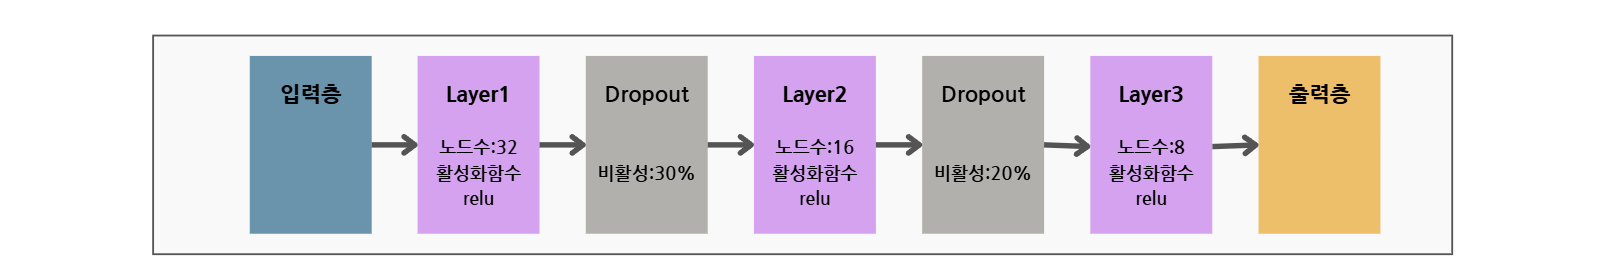

In [43]:
# (코드 셀) 코드의 빈칸을 채우고 실행하세요.
# 이미지 토폴로지에 기반한 모델 설계
model = Sequential([
    Dense(units=32, activation='relu', input_shape=(X_train_scaled.shape[1],)),
    Dropout(0.3),
    Dense(16, activation='relu'),
    Dropout(0.2),
    Dense(units=8, activation='relu'),

    # 출력층
    Dense(units=1, activation='sigmoid')
])

# 설계 결과 확인
model.summary()

C:\Users\kun99\anaconda3\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense (Dense)                        │ (None, 32)                  │             640 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 32)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 16)                  │             528 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 16)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 8)                   │             136 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_3 (Dense)                      │ (None, 1)                   │               9 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 1,313 (5.13 KB)

 Trainable params: 1,313 (5.13 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# (11-1) 여기에 답안을 입력하세요(실행 불필요).

In [ ]:
# (11-2) 여기에 답안을 입력하세요(실행 불필요).

#### **12. 학습 과정에서 검증 데이터의 손실이 개선되지 않으면 학습을 중단하고, 최적의 성능을 보인 모델을 저장하기 위해 콜백(Callback) 설정과 컴파일을 완료하려 합니다. 아래 가이드에 따라 코드의 빈칸을 채우고 실행하세요.**
---
* **대상 모델**: **`model`** (11번 문항에서 설계됨)
* **Callback 설정**
    * **EarlyStopping**: 검증 손실(**`val_loss`**)이 **10** epoch 동안 개선되지 않으면 학습을 조기 종료하도록 설정하세요.
    * **ModelCheckpoint**: 검증 정확도(**`val_accuracy`**)가 가장 높은 최적의 모델을 **'best_churn_model.keras'** 파일로 저장하도록 설정하고, **`save_best_only=True`** 옵션을 적용하세요.
* **모델 컴파일**
    * 최적화 함수(optimizer)는 **'adam'** 으로 설정하세요.
    * 손실 함수(loss)는 이진 분류 문제에 적합한 함수를 설정하세요.
    * 평가지표(metrics)는 **['accuracy']** 로 지정하세요.
* **빈칸 채우기**: 아래 코드 셀의 **`<#12-1>`**, **`<#12-2>`**, **`<#12-3>`** 빈칸을 알맞게 채우세요.
---

In [44]:
# (코드 셀) 코드의 빈칸을 채우고 실행하세요.
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

# 1. Callback 설정
es = EarlyStopping(monitor='val_loss', patience=10)
mc = ModelCheckpoint(filepath='best_churn_model.keras',
                     monitor='val_accuracy',
                     save_best_only=True)

# 2. 모델 컴파일
model.compile(optimizer='adam',
              loss='binary_crossentropy',
              metrics=['accuracy'])

In [ ]:
# (12-1) 여기에 답안을 입력하세요(실행 불필요).

In [ ]:
# (12-2) 여기에 답안을 입력하세요(실행 불필요).

In [ ]:
# (12-3) 여기에 답안을 입력하세요(실행 불필요).

#### **13. 설계와 컴파일이 완료된 딥러닝 모델에 데이터를 입력하여 학습을 진행하고, 그 과정을 기록하려 합니다. 아래 가이드에 따라 (13-1) 모델을 학습시키고, (13-2) 설정을 확인하세요.**
---
* **(13-1) 준비된 데이터와 콜백 함수를 사용하여 딥러닝 모델 학습을 수행하세요.**
    * 전처리가 완료된 훈련 데이터셋(**`X_train_scaled`**, **`y_train`**)으로 모델을 학습시키세요.
    * 학습 하이퍼파라미터 설정: **`epochs=100`**, **`batch_size=32`**
    * 검증 데이터(**`validation_data`**)로 **`X_valid_scaled`** 와 **`y_valid`** 를 사용하세요.
    * 12번 문항에서 설정한 **`es`**(EarlyStopping)와 **`mc`**(ModelCheckpoint) 콜백을 모두 적용하세요.
    * 학습 과정의 모든 기록은 **`history`** 변수에 저장하세요.
* **(13-2) 본 문항에서 지정한 하이퍼파라미터 중 가중치 업데이트를 위해 한 번에 입력되는 데이터의 묶음 단위는 얼마로 설정되어 있나요?**
---

In [45]:
history = model.fit(X_train_scaled, y_train, epochs=100, batch_size=32,
                    validation_data=(X_valid_scaled, y_valid),
                    callbacks=[es, mc])

Epoch 1/100
110/110 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.5334 - loss: 0.6944 - val_accuracy: 0.6693 - val_loss: 0.6489
Epoch 2/100
110/110 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.6920 - loss: 0.6095 - val_accuracy: 0.7900 - val_loss: 0.5154
Epoch 3/100
110/110 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7820 - loss: 0.4769 - val_accuracy: 0.8693 - val_loss: 0.3384
Epoch 4/100
110/110 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8440 - loss: 0.3776 - val_accuracy: 0.9007 - val_loss: 0.2600
Epoch 5/100
110/110 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8686 - loss: 0.3132 - val_accuracy: 0.9100 - val_loss: 0.2246
Epoch 6/100
110/110 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8740 - loss: 0.2887 - val_accuracy: 0.9167 - val_loss: 0.2042
Epoch 7/100
110/110 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8851 - loss: 0.2655 - val_accuracy: 0.9260 - val_loss: 0.1844
Epoch 8/100
110/110 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8943 - loss: 0.2444 - val_accu

In [ ]:
# (13-2) 여기에 답안을 입력하세요(실행 불필요).

#### **14. 학습 과정에서 저장된 최적의 딥러닝 모델을 로드하여, 새로운 고객의 이탈 여부를 최종 예측하려 합니다. 아래 가이드에 따라 (14-1) 예측을 수행하고 (14-2) 결과를 확인하세요.**
---
* **(14-1) 저장된 최적 모델을 불러와 새로운 데이터에 대한 이탈 여부를 판별하세오.**
    * 대상 데이터셋: **`sample_data`** (스케일링이 완료된 1명의 고객 데이터)
    * 12번 문항에서 저장한 최적 모델 파일인 **'best_churn_model.keras'** 를 불러와 **`best_model`** 변수에 저장하세요.
    * 불러온 모델을 사용하여 **`sample_data`** 의 이탈 확률을 예측하세요.
    * 예측된 확률이 **0.5 이상이면 1(이탈)**, **0.5 미만이면 0(유지)** 으로 변환하여 최종 결과를 출력하세요.
* **(14-2) 새로운 고객(sample_data)에 대해 모델이 최종적으로 예측한 결과(0:유지 또는 1:이탈)는 무엇인가요?**
---

> **<span style="color:red">아래 코드를 사전에 </span> 실행하세요.**
>

In [46]:
# 이 코드를 먼저 실행하시오.
from tensorflow.keras.models import load_model
import numpy as np
sample_data = np.array([[1.0, 0.97, 1.27, -0.19, -1.0, -1.15, 0.0, -0.75, 1.0, 0.0, 1.0, 0.0, 0.0, 0.0, 0.0, 0.0, 1.0, 0.0, 0.0]])

In [47]:
best_model = load_model('best_churn_model.keras')

sample_pred = best_model.predict(sample_data)

result = 1 if sample_pred >= 0.5 else 0

print(result)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 134ms/step
0


In [1]:
# (14-2) 여기에 답안을 입력하세요(실행 불필요).
# (예: 유지, 이탈)